# 19_04 — Evaluación predictiva · **Escenario C: interacciones intra-curva + tendencia lineal** · **barrido en $M$**

Paso **3b** del ciclo. Supone que `19_03_convergencia` dio veredicto ✓ **en cada
punto del barrido**; si las cadenas de un $M$ no convergieron, sus cifras aquí
no significan nada y tampoco su lugar en la comparación de §11.

## Qué se reporta

| Sección | Qué responde |
|---|---|
| 4 | métricas puntuales y distribucionales, **train vs test**, por $M$ |
| 5 | bandas de credibilidad sobre la serie de cada score |
| 6 | intervalos sobre la curva, en extractos cada 10 períodos |
| 7 | ventana móvil: cómo evoluciona el error al cruzar $T_0$ |
| 8 | calibración: PIT por bloque |
| 9 | comparación con las líneas base de `19_01` |
| **9.1** | **bimodalidad de la predictiva y calibración por ambigüedad, contra el oráculo** |
| **11** | **el barrido: todo lo anterior cruzado entre $M$** |

Todo el cálculo vive en `fit/` y todo el dibujo en `graphics/`: este notebook
sólo orquesta.


## 1. Imports, rutas y artefactos

In [2]:
1

1

In [3]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import loadmat

from model_psbp_fd.pipelines import (
    cargar_curvas, cargar_curvas_true, cargar_fpca, cargar_estandarizador,
    cargar_datasets_ar, cargar_hiperparametros, cargar_config_evaluacion,
)
from model_psbp_fd.functions_models import DataStandardizer
from model_psbp_fd.models.pspb_fd_v3 import PSBPPredictor, PropagadorFuncional

from model_psbp_fd.fit import (
    # puntual
    rmse_por_coeficiente, r2_por_columna, razon_dispersion, mise, rmse_funcional,
    # distribucional muestral
    crps_muestral, energy_score, cobertura, intervalo_muestral,
    pit_muestral, diagnostico_pit,
    # agrupación de cadenas y ventana móvil
    agrupar_momentos, ventana_movil_scores, ventana_movil_funcional,
    # calibración condicional por el estado verdadero del generador
    cobertura_condicional,
)
from model_psbp_fd.graphics import (
    plot_ventana_movil, plot_bandas_serie, plot_extractos_curvas,
    plot_calibracion_pit, plot_scatter_theta,
)
from model_psbp_fd.utils import get_project_root

plt.style.use("seaborn-v0_8-darkgrid")
%matplotlib inline

In [4]:
PROJECT_ROOT = get_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# == [CONFIG] ================================================================
# BARRIDO EN M. Debe ser el mismo que en 19_01, 19_03 y psbp_fd_iteracion.m.
# ESCENARIO_ID es una CADENA en esta corrida; el .m usa %s por el mismo motivo.
BASENAME, ESCENARIO_ID, REPLICA_ID = "escenario", "C", 1
M_FPCA_LIST = (2, 3, 4)

# Los puntos sin trazas se SALTAN con aviso, para poder ir mirando el barrido a
# medida que MATLAB termina cada M. En False, la falta de trazas es un error.
SALTAR_M_SIN_TRAZAS = True
# ============================================================================

M_FPCA_LIST = tuple(int(m) for m in M_FPCA_LIST)
assert len(set(M_FPCA_LIST)) == len(M_FPCA_LIST), "M_FPCA_LIST tiene repetidos."

EXPERIMENT_BASE = f"{BASENAME}_{ESCENARIO_ID}_r{REPLICA_ID:02d}"


def experiment_id(M: int) -> str:
    return f"{EXPERIMENT_BASE}_m{M:02d}"


def rutas(M: int) -> dict:
    eid = experiment_id(M)
    p = {
        "raw":          PROJECT_ROOT / "data" / "simulaciones" / "raw" / eid,
        "functional":   PROJECT_ROOT / "data" / "simulaciones" / "processed" / "functional" / eid,
        "predict":      PROJECT_ROOT / "data" / "simulaciones" / "processed" / "predict" / eid,
        "out_report":   PROJECT_ROOT / "reports" / "simulaciones" / eid,
        "out_artefact": PROJECT_ROOT / "artefact" / "simulaciones" / eid,
    }
    for r in p.values():
        r.mkdir(parents=True, exist_ok=True)
    return p


PATHS_M      = {M: rutas(M) for M in M_FPCA_LIST}
PATH_BARRIDO = PROJECT_ROOT / "reports" / "simulaciones" / f"{EXPERIMENT_BASE}_barrido_M"
PATH_BARRIDO.mkdir(parents=True, exist_ok=True)

print(f"barrido en M : {list(M_FPCA_LIST)}")
for M in M_FPCA_LIST:
    print(f"  M={M}  ->  {experiment_id(M)}")
print(f"salidas cruzadas (§11) : {PATH_BARRIDO}   (archivos 85-89)")

barrido en M : [2, 3, 4]
  M=2  ->  escenario_C_r01_m02
  M=3  ->  escenario_C_r01_m03
  M=4  ->  escenario_C_r01_m04
salidas cruzadas (§11) : C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\simulaciones\escenario_C_r01_barrido_M   (archivos 85-89)


In [5]:
# Estado por punto del barrido. Nada de lo que sigue usa variables globales del
# experimento: todo se lee de EST[M].
EST = {}
saltados = []

for M in M_FPCA_LIST:
    P = PATHS_M[M]
    if not (P["functional"] / "datasets_manifest.json").exists():
        saltados.append((M, "sin datasets_manifest.json - falta correr 19_01"))
        continue

    dfs_train, manifest = cargar_datasets_ar(P, bloque="train")
    dfs_test,  _        = cargar_datasets_ar(P, bloque="test")
    hp_json     = cargar_hiperparametros(P)
    eval_config = cargar_config_evaluacion(P)

    component_idx = manifest["component_idx"]
    n_components  = len(component_idx)
    assert n_components == M, (
        f"{experiment_id(M)} declara M={M} pero su manifest tiene "
        f"{n_components} componentes.")
    assert manifest["scores_scale"] == "standardized_zscore_ddof0"

    EST[M] = {
        "paths": P, "eid": experiment_id(M),
        "dfs_train": dfs_train, "dfs_test": dfs_test, "manifest": manifest,
        "hp_json": hp_json, "eval_config": eval_config,
        "component_idx": component_idx, "n_components": n_components,
        "cov_names": manifest["cov_names"],
        "n_lags": int(manifest["n_lags"]),
        "T": int(manifest["T"]), "T0": int(manifest["T0"]),
        "n_iter": int(hp_json["n_iter"]),
        "mcmc_cfg": hp_json["mcmc_config"],
        "burn": int(hp_json["mcmc_config"]["burn"]),
        # Parámetros de evaluación: se LEEN del artefacto, no se redeclaran.
        "nivel": float(eval_config.get("nivel_credibilidad", 0.95)),
        "modo_residuo": eval_config.get("modo_residuo", "ninguno"),
        "objetivo": eval_config.get("objetivo_evaluacion", "curva_verdadera"),
        "ventanas_w": list(eval_config.get("ventana_movil", {}).get("w", [10, 20, 40])),
    }
    EST[M]["n_post"] = EST[M]["mcmc_cfg"]["nsim"] - EST[M]["burn"]

assert EST, "Ningún punto del barrido tiene datos. Ejecuta 19_01 primero."

for M, e in EST.items():
    print(f"M={M}  T={e['T']} T0={e['T0']} n_lags={e['n_lags']} "
          f"componentes={e['n_components']}  nivel={e['nivel']}  "
          f"modo_residuo={e['modo_residuo']!r}  objetivo={e['objetivo']!r}")
for M, motivo in saltados:
    print(f"  ! M={M} saltado: {motivo}")

# La comparación entre M sólo tiene sentido si el diseño de observación, la
# partición y el objetivo de evaluación son los mismos en todos los puntos: si
# no, las diferencias mezclarían el efecto de M con el de otra cosa.
_comun = {M: (e["T"], e["T0"], e["n_lags"], e["nivel"], e["modo_residuo"],
              e["objetivo"], tuple(e["ventanas_w"]), e["n_iter"],
              e["mcmc_cfg"]["nsim"], e["mcmc_cfg"]["N"], e["burn"])
          for M, e in EST.items()}
if len(set(_comun.values())) > 1:
    print("\n! Los puntos del barrido NO comparten diseño/evaluación:")
    for M, v in _comun.items():
        print(f"    M={M}: {v}")
    raise AssertionError(
        "El barrido en M exige T, T0, n_lags, nivel, modo_residuo, objetivo, "
        "ventanas y configuración MCMC idénticos. Regenera los puntos que "
        "difieren antes de comparar.")
print("\nOK todos los puntos comparten diseño de observación, partición, "
      "objetivo de evaluación y configuración MCMC.")

# Alias de las cantidades comunes, para no repetir EST[M][...] en cada celda.
T          = EST[next(iter(EST))]["T"]
T0         = EST[next(iter(EST))]["T0"]
N_LAGS     = EST[next(iter(EST))]["n_lags"]
NIVEL      = EST[next(iter(EST))]["nivel"]
MODO_RESIDUO = EST[next(iter(EST))]["modo_residuo"]
OBJETIVO   = EST[next(iter(EST))]["objetivo"]
VENTANAS_W = EST[next(iter(EST))]["ventanas_w"]
W_REF      = VENTANAS_W[len(VENTANAS_W) // 2]
print(f"ventanas w = {VENTANAS_W}   ·   referencia w={W_REF}")

M=3  T=400 T0=280 n_lags=1 componentes=3  nivel=0.95  modo_residuo='ninguno'  objetivo='curva_verdadera'
  ! M=2 saltado: sin datasets_manifest.json - falta correr 19_01
  ! M=4 saltado: sin datasets_manifest.json - falta correr 19_01

OK todos los puntos comparten diseño de observación, partición, objetivo de evaluación y configuración MCMC.
ventanas w = [10, 20, 40]   ·   referencia w=20


In [6]:
for M in EST:
    e, P = EST[M], EST[M]["paths"]

    fpca = cargar_fpca(P)
    _ver = fpca.verificar()
    assert _ver["todo_ok"], f"[M={M}] las identidades FPCA no se cumplen: {_ver}"

    std = cargar_estandarizador(P, DataStandardizer)
    X_obs, grilla = cargar_curvas(P)          # (T, G) con ruido
    X_true        = cargar_curvas_true(P)     # (T, G) verdadera - el objetivo

    assert e["component_idx"] == list(range(fpca.M)), (
        "La propagación funcional necesita el vector completo de scores en "
        f"orden; [M={M}] COMPONENT_IDX={e['component_idx']} y M={fpca.M}.")

    e.update({"fpca": fpca, "std": std, "X_obs": X_obs, "X_true": X_true,
              "grilla": grilla, "M_fpca": fpca.M, "K": fpca.K,
              "Psi_grid": fpca.Psi_grid, "mu_grid": fpca.mu_grid,
              "SCORES": fpca.SCORES,
              "var_explicada": float(fpca.meta["var_explained"])})

    print(f"M={M}  FPCA M={fpca.M} K={fpca.K}  var. explicada="
          f"{e['var_explicada']:.4%}  ·  curvas {X_true.shape}  "
          f"grilla {grilla.shape}")

# Las curvas y la grilla son las MISMAS en todos los puntos: el generador y la
# semilla no dependen de M, sólo cambia cuántas componentes se retienen. Si no
# coincidieran, el MISE de dos M no sería sobre los mismos datos.
_M0 = next(iter(EST))
for M in EST:
    assert np.allclose(EST[M]["X_true"], EST[_M0]["X_true"]), (
        f"[M={M}] las curvas verdaderas difieren de las de M={_M0}: los puntos "
        "del barrido no salen de la misma simulación.")
    assert np.allclose(EST[M]["grilla"], EST[_M0]["grilla"])
grilla = EST[_M0]["grilla"]
X_true = EST[_M0]["X_true"]
X_obs  = EST[_M0]["X_obs"]
print(f"\nOK las {len(EST)} representaciones vienen de la MISMA simulación: "
      "las diferencias entre M son de representación, no de datos.")
print(f"sd(observada - verdadera) = {(X_obs - X_true).std():.4f}   "
      "<- el ruido que el modelo NO debe predecir")

M=3  FPCA M=3 K=7  var. explicada=99.5513%  ·  curvas (400, 75)  grilla (75,)

OK las 1 representaciones vienen de la MISMA simulación: las diferencias entre M son de representación, no de datos.
sd(observada - verdadera) = 0.2503   <- el ruido que el modelo NO debe predecir


## 2. Trazas MCMC

Una lectura por punto del barrido. El `feature_names` del `.mat` se verifica
contra las columnas del dataset: con $M$ distintos el número de covariables
cambia, y un `.mat` del punto equivocado se detectaría aquí y no más adelante
como un resultado raro.

In [7]:
_CLAVES_TRAZA = ["betajhout", "beta0hout", "tauhout", "alphahout", "psijhout",
                 "Gammajhout", "gammajhout", "pijout", "wjout", "osumout", "inEout"]


def ruta_traza(P, fpc_idx, chain):
    return P["out_artefact"] / f"chain_fpc_{fpc_idx}_iter{chain:02d}.mat"


def leer_traza(path):
    m = loadmat(str(path))
    traces = {k: np.asarray(m[k], dtype=np.float64) for k in _CLAVES_TRAZA}
    burn = int(np.asarray(m["burn"]).ravel()[0])
    feat = str(np.atleast_1d(m["feature_names"]).ravel()[0]).split(",")
    return traces, burn, feat


class ModeloTraza:
    def __init__(self, traces, burn, feature_names):
        self.traces = traces
        self.feature_names_ = list(feature_names)
        self.burn = int(burn)
        self.predictor_ = PSBPPredictor(traces=traces, burn=burn)
        self.n_features_ = int(self.predictor_.n_features_)

    def _diseno(self, df):
        Xp = np.asarray(df.iloc[:, 1:], dtype=float)
        return np.hstack([np.ones((Xp.shape[0], 1)), Xp])

    def momentos(self, df):
        return self.predictor_.momentos_predictivos(self._diseno(df))

    def muestrear(self, df, d=1, seed=None):
        return self.predictor_.muestrear(self._diseno(df), d, seed=seed)

In [8]:
sin_trazas = []

for M in list(EST):
    e, P = EST[M], EST[M]["paths"]
    ci, n_comp, n_iter = e["component_idx"], e["n_components"], e["n_iter"]

    faltan = [ruta_traza(P, ci[k] + 1, c + 1).name
              for k in range(n_comp) for c in range(n_iter)
              if not ruta_traza(P, ci[k] + 1, c + 1).exists()]
    if faltan:
        msg = f"faltan {len(faltan)} trazas: {faltan[:3]}{'...' if len(faltan) > 3 else ''}"
        if not SALTAR_M_SIN_TRAZAS:
            raise AssertionError(f"[M={M}] {msg}\nEjecuta psbp_fd_iteracion.m.")
        sin_trazas.append((M, msg))
        del EST[M]
        continue

    models_chains = {k: {} for k in range(n_comp)}
    for k in range(n_comp):
        esperado = list(e["dfs_train"][k].columns[1:])
        for c in range(n_iter):
            traces, burn, feat = leer_traza(ruta_traza(P, ci[k] + 1, c + 1))
            assert feat == esperado, (
                f"[M={M} k={k} c={c+1}] feature_names != columnas del dataset:\n"
                f"  mat  = {feat}\n  train= {esperado}")
            models_chains[k][c] = ModeloTraza(traces, burn, feat)
    e["models_chains"] = models_chains
    print(f"OK M={M}: {n_comp} x {n_iter} cadenas · {e['n_post']} draws "
          f"posteriores c/u  ·  p={models_chains[0][0].n_features_}")

assert EST, ("Ningún punto del barrido tiene trazas. Ejecuta "
             "psbp_fd_iteracion.m con M_FPCA_LIST antes de este notebook.")
for M, motivo in sin_trazas:
    print(f"! M={M} saltado: {motivo}")

M_OK = tuple(sorted(EST))
print(f"\npuntos evaluables: M = {list(M_OK)}")

OK M=3: 3 x 3 cadenas · 1500 draws posteriores c/u  ·  p=3

puntos evaluables: M = [3]


## 3. Predicción a $h=1$ sobre la serie completa

Los dos bloques se concatenan en **una sola serie de orígenes**
$t=N_{lags}+1,\dots,T$. Ésa es la diferencia con el flujo anterior, que sólo
evaluaba el bloque de prueba: sin el tramo de entrenamiento no hay con qué
comparar el salto en $T_0$, que es la lectura principal de la ventana móvil.

En todos los orígenes la predicción usa los **rezagos reales** —nunca
predicciones encadenadas—, de modo que el horizonte es 1 en todo el recorrido y
el modelo no se reentrena en ningún punto.

### Memoria

Con el barrido hay que sostener un estado por $M$, así que las muestras
funcionales `X_draws` —$(S', n, G)$, el objeto más grande de todo el
notebook— **se liberan dentro del bucle**: el `energy score` y los cuantiles de
la banda se calculan en el momento y lo que sobrevive son los resúmenes
$(n, G)$. Sin eso, tres puntos del barrido pedirían varios cientos de MB sin
ninguna necesidad.

In [9]:
# Número de extracciones de la predictiva por draw posterior. El total es
#     S = (nsim - burn) × S_POR_ITER × n_cadenas
# y d=1 ya da varios miles: subirlo sólo reduce el error Monte Carlo de estimar
# los cuantiles, no cambia la predictiva.
S_POR_ITER = 10
S_FUNC     = 500        # muestras funcionales tras adelgazar
SEED_PRED  = 20260823
CADA       = 20         # [CONFIG] un extracto de curva cada CADA períodos

# Serie de orígenes: es la MISMA en todos los M (T, T0 y n_lags son comunes).
t_orig   = np.arange(N_LAGS + 1, T + 1)      # tiempo del experimento, base-1
n_orig   = len(t_orig)
T0_orig  = T0 - N_LAGS                       # corte dentro de la serie de orígenes
es_train = t_orig <= T0
print(f"orígenes evaluados: {n_orig}  (train {es_train.sum()} · test {(~es_train).sum()})")

_mem = sum(EST[M]["n_post"] * S_POR_ITER * EST[M]["n_iter"] * n_orig
           * EST[M]["n_components"] * 4 for M in M_OK) / 1e9
print(f"SC_draws de TODO el barrido reservará {_mem * 1e3:.0f} MB en float32")
assert _mem < 2.0, (
    f"SC_draws pediría {_mem:.1f} GB sumando los M. Baja S_POR_ITER o acorta "
    "M_FPCA_LIST antes de continuar.")
print(f"X_draws se libera dentro del bucle: pico ≈ "
      f"{S_FUNC * n_orig * len(grilla) * 8 / 1e6:.0f} MB (un solo M a la vez)")

orígenes evaluados: 399  (train 279 · test 120)
SC_draws de TODO el barrido reservará 215 MB en float32
X_draws se libera dentro del bucle: pico ≈ 120 MB (un solo M a la vez)


In [10]:
for M in M_OK:
    e = EST[M]
    n_comp, n_iter, n_post = e["n_components"], e["n_iter"], e["n_post"]
    ci = e["component_idx"]

    dfs_full = {k: pd.concat([e["dfs_train"][k], e["dfs_test"][k]],
                             ignore_index=True) for k in range(n_comp)}
    assert len(dfs_full[0]) == n_orig, f"[M={M}] {len(dfs_full[0])} != {n_orig}"

    # -- momentos y extracciones por score, agrupando cadenas ----------------
    #    momentos : ley de varianza total entre cadenas (fit.agrupar_momentos)
    #    muestras : concatenación, que es la mezcla de igual peso
    Y_obs = np.column_stack([dfs_full[k].iloc[:, 0].to_numpy()
                             for k in range(n_comp)])
    Y_hat = np.empty_like(Y_obs)
    Y_sd  = np.empty_like(Y_obs)

    S_POR_CADENA = n_post * S_POR_ITER
    S_total      = S_POR_CADENA * n_iter
    SC_draws     = np.empty((S_total, n_orig, n_comp), dtype=np.float32)

    for k in range(n_comp):
        medias, sds = [], []
        for j, c in enumerate(sorted(e["models_chains"][k])):
            mom = e["models_chains"][k][c].momentos(dfs_full[k])
            medias.append(mom["media"])
            sds.append(mom["sd"])          # PREDICTIVA (v3), no la del centro
            muestras_c = e["models_chains"][k][c].muestrear(
                dfs_full[k], S_POR_ITER, seed=SEED_PRED + 1000 * k + c + 97 * M)
            assert muestras_c.shape == (S_POR_CADENA, n_orig), (
                f"[M={M} k={k} c={c}] muestrear devolvió {muestras_c.shape}; se "
                f"esperaba ({S_POR_CADENA}, {n_orig}).")
            SC_draws[j * S_POR_CADENA:(j + 1) * S_POR_CADENA, :, k] = muestras_c
            del muestras_c
        Y_hat[:, k], Y_sd[:, k] = agrupar_momentos(np.column_stack(medias),
                                                   np.column_stack(sds))

    li_s, ls_s = intervalo_muestral(SC_draws, nivel=NIVEL)     # (n_orig, M)

    # -- propagación a la curva ---------------------------------------------
    paso_thin = max(1, S_total // S_FUNC)
    propagador = PropagadorFuncional(e["Psi_grid"], e["mu_grid"],
                                     estandarizador=e["std"],
                                     modo_residuo=MODO_RESIDUO)
    X_draws = propagador.curvas_desde_scores(SC_draws[::paso_thin], seed=SEED_PRED)
    X_pred  = X_draws.mean(axis=0)                              # (n, G)
    li_f = np.quantile(X_draws, (1 - NIVEL) / 2, axis=0)
    ls_f = np.quantile(X_draws, 1 - (1 - NIVEL) / 2, axis=0)

    X_true_ev = X_true[N_LAGS:]      # (n_orig, G) VERDADERA - contra esto se evalúa
    X_obs_ev  = X_obs[N_LAGS:]       # (n_orig, G) observada, sólo para las figuras
    X_proj    = e["fpca"].reconstruct(e["SCORES"])[N_LAGS:]     # piso de la representación

    # El energy score necesita las muestras funcionales completas, así que se
    # calcula AQUÍ y no en §4: es lo único que impide liberar X_draws.
    energia = {etq: energy_score(X_true_ev[m], X_draws[:, m, :],
                                 max_pares=2000, seed=0)
               for etq, m in (("train", es_train), ("test", ~es_train))}
    S_funcional = int(X_draws.shape[0])
    del X_draws

    e.update({"dfs_full": dfs_full, "Y_obs": Y_obs, "Y_hat": Y_hat, "Y_sd": Y_sd,
              "SC_draws": SC_draws, "li_s": li_s, "ls_s": ls_s,
              "X_pred": X_pred, "li_f": li_f, "ls_f": ls_f, "X_proj": X_proj,
              "energia": energia, "S_total": int(S_total),
              "S_funcional": S_funcional, "paso_thin": paso_thin})

    print(f"M={M}: S={S_total} extracciones por score · funcionales "
          f"{S_funcional} (1 de cada {paso_thin}) · SC_draws "
          f"{SC_draws.nbytes / 1e6:.0f} MB")
    print(f"       MISE del TRUNCAMIENTO (test) = "
          f"{mise(X_true_ev[~es_train], X_proj[~es_train], grilla):.6f}"
          "   <- ningún modelo sobre esta representación baja de ahí")

X_true_ev = X_true[N_LAGS:]
X_obs_ev  = X_obs[N_LAGS:]

M=3: S=45000 extracciones por score · funcionales 500 (1 de cada 90) · SC_draws 215 MB
       MISE del TRUNCAMIENTO (test) = 0.011269   <- ningún modelo sobre esta representación baja de ahí


## 4. Métricas, entrenamiento contra prueba

La comparación train/test es la que separa el ajuste de la generalización.
En el Escenario B el proceso es **estacionario** —$\lVert\Psi
Vert_{HS}=0.9<1$ y
$\lvert s_t
vert = 1$—, de modo que **las dos columnas deberían parecerse**: si
el test se degrada mucho hay sobreajuste, no cambio de régimen. La comparación
que decide el escenario no está aquí sino en `19_05 §7.1`, contra el techo del
oráculo.

Una tabla por $M$; el cruce entre $M$ está en §11.

In [11]:
def metricas_scores(M):
    """Métricas puntuales y distribucionales por score y bloque."""
    e = EST[M]
    filas = []
    for etiqueta, mask in (("train", es_train), ("test", ~es_train)):
        for k in range(e["n_components"]):
            y, p = e["Y_obs"][mask, k], e["Y_hat"][mask, k]
            z    = e["SC_draws"][:, mask, k]
            cob  = cobertura(y, e["li_s"][mask, k], e["ls_s"][mask, k])
            pit  = pit_muestral(y, z)
            filas.append({
                "bloque": etiqueta,
                "FPC":    f"FPC {e['component_idx'][k] + 1}",
                "RMSE":   float(rmse_por_coeficiente(y[:, None], p[:, None])[0]),
                "R2":     float(r2_por_columna(y[:, None], p[:, None], centrar=True)[0]),
                "sd_ratio": float(razon_dispersion(y[:, None], p[:, None])[0]),
                "CRPS":   float(crps_muestral(y, z).mean()),
                f"Cob{int(NIVEL*100)}": cob["cobertura"],
                "Ancho":  cob["ancho_medio"],
                "PIT_ks": float(diagnostico_pit(pit)["ks"]),
                "PIT_forma": diagnostico_pit(pit)["forma"],
                "n":      int(mask.sum()),
            })
    return pd.DataFrame(filas).set_index(["bloque", "FPC"])


for M in M_OK:
    e = EST[M]
    met_df = metricas_scores(M)
    met_df.to_csv(e["paths"]["out_report"] / "50_metricas_scores.csv")
    e["met_df"] = met_df

    _num = [c for c in met_df.columns if met_df[c].dtype.kind == "f"]
    display(met_df.style
        .format({c: "{:.4f}" for c in _num})
        .background_gradient(subset=["RMSE", "CRPS"], cmap="RdYlGn_r")
        .background_gradient(subset=["R2"], cmap="RdYlGn", vmin=0, vmax=1)
        .background_gradient(subset=[f"Cob{int(NIVEL*100)}"], cmap="RdYlGn",
                             vmin=0.80, vmax=1.0)
        .set_caption(f"M={M} - métricas por score y bloque · CRPS y cobertura "
                     "desde la predictiva MUESTRAL"))

    deg = met_df.loc["test", "RMSE"].mean() / met_df.loc["train", "RMSE"].mean()
    e["degradacion_rmse"] = float(deg)
    print(f"[M={M}] RMSE test / RMSE train = {deg:.3f}"
          + ("   OK sin degradación apreciable" if deg < 1.15
             else "   <- el modelo se degrada fuera de muestra"))

[M=3] RMSE test / RMSE train = 1.174   <- el modelo se degrada fuera de muestra


In [12]:
# Métricas funcionales, contra la curva VERDADERA.
for M in M_OK:
    e = EST[M]
    filas_f = []
    for etq, mask in (("train", es_train), ("test", ~es_train)):
        dentro = ((X_true_ev[mask] >= e["li_f"][mask]) &
                  (X_true_ev[mask] <= e["ls_f"][mask]))
        filas_f.append({
            "bloque": etq,
            "MISE":   mise(X_true_ev[mask], e["X_pred"][mask], grilla),
            "RMSE_f": rmse_funcional(X_true_ev[mask], e["X_pred"][mask], grilla),
            "MISE_truncamiento": mise(X_true_ev[mask], e["X_proj"][mask], grilla),
            "energy": e["energia"][etq],
            f"Cob{int(NIVEL*100)}_puntual": float(dentro.mean()),
            "ancho_medio": float((e["ls_f"][mask] - e["li_f"][mask]).mean()),
            "n": int(mask.sum()),
        })
    fun_df = pd.DataFrame(filas_f).set_index("bloque")
    fun_df.to_csv(e["paths"]["out_report"] / "51_metricas_funcionales.csv")
    e["fun_df"] = fun_df

    display(fun_df.style
            .format("{:.6f}", subset=["MISE", "RMSE_f", "MISE_truncamiento"])
            .format("{:.4f}", subset=["energy", f"Cob{int(NIVEL*100)}_puntual",
                                      "ancho_medio"])
            .set_caption(f"M={M} - métricas funcionales contra la curva "
                         "VERDADERA · banda sin residuo de representación"))

    frac = fun_df["MISE_truncamiento"] / fun_df["MISE"]
    e["frac_truncamiento"] = {b: float(frac[b]) for b in fun_df.index}
    print(f"[M={M}] fracción del MISE atribuible al truncamiento FPCA:")
    for b in fun_df.index:
        print(f"    {b:5s}: {frac[b]:.1%}"
              + ("   <- el techo de la representación domina; subir M rinde más "
                 "que mejorar el modelo" if frac[b] > 0.7 else ""))

print(f"\nLa cobertura es PUNTUAL (cada tau por separado), NO simultánea sobre "
      f"la curva.")

,MISE,RMSE_f,MISE_truncamiento,energy,Cob95_puntual,ancho_medio,n
bloque,,,,,,,
train,1.197137,1.094138,0.009642,5.8642,0.9557,4.4041,279
test,1.779368,1.333930,0.011269,6.8580,0.9257,5.1164,120


[M=3] fracción del MISE atribuible al truncamiento FPCA:
    train: 0.8%
    test : 0.6%

La cobertura es PUNTUAL (cada tau por separado), NO simultánea sobre la curva.


## 5. Bandas de credibilidad sobre la serie de scores

[plot_bandas_serie] inicio (3 pasos)
  1/3 (33.3%) t=0.0s eta=0.0s  FPC 1: cob train=0.964 (+0.014) test=0.908 (-0.042) | ancho train=2.927 test=3.438 | 21/399 fuera
  2/3 (66.7%) t=0.0s eta=0.0s  FPC 2: cob train=0.957 (+0.007) test=0.950 (+0.000) | ancho train=3.78 test=3.799 | 18/399 fuera
  3/3 (100.0%) t=0.1s eta=0.0s  FPC 3: cob train=0.978 (+0.028) test=0.933 (-0.017) | ancho train=2.93 test=3.971 | 14/399 fuera
[plot_bandas_serie] listo: 3 pasos en 0.9s  -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\simulaciones\escenario_C_r01_m03\52_bandas_scores.png


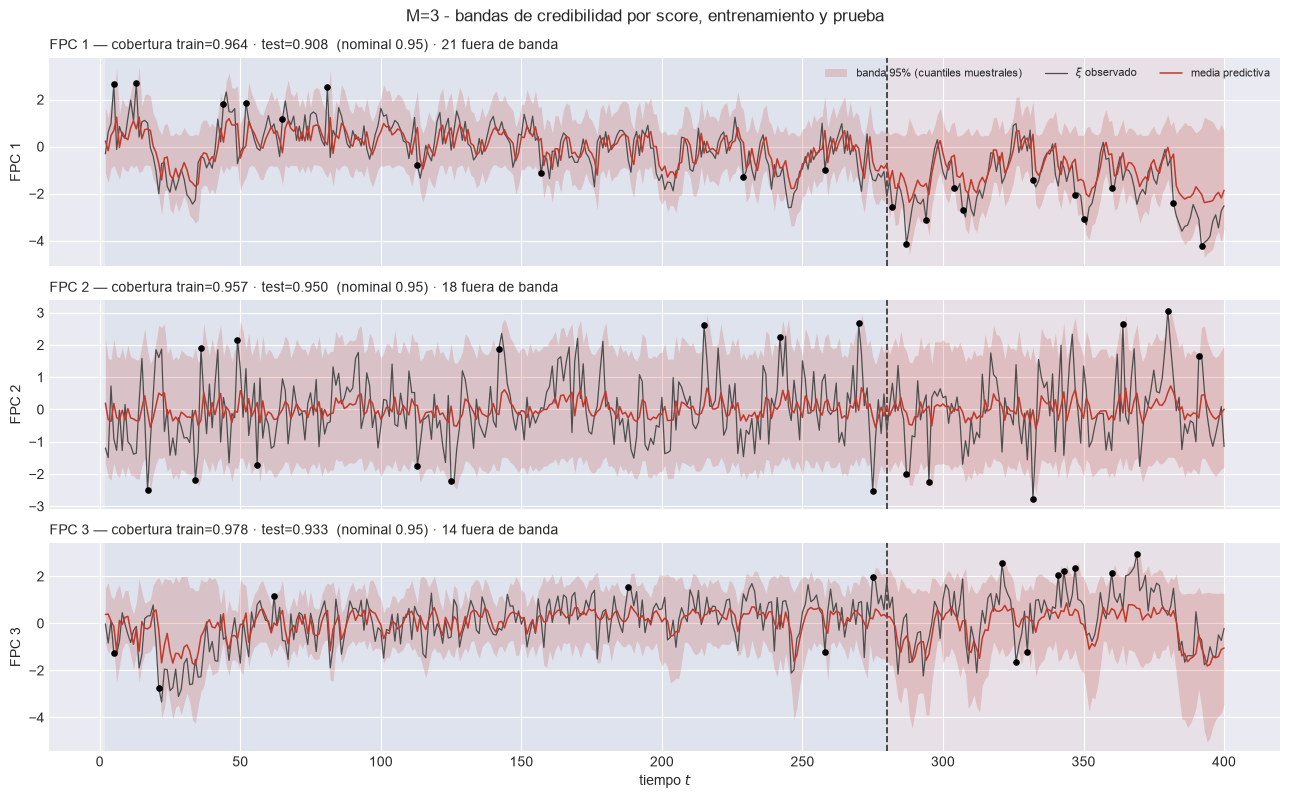

In [13]:
for M in M_OK:
    e = EST[M]
    plot_bandas_serie(
        e["Y_obs"], e["Y_hat"], e["li_s"], e["ls_s"], T0, t=t_orig,
        etiquetas=[f"FPC {i + 1}" for i in e["component_idx"]], nivel=NIVEL,
        title=f"M={M} - bandas de credibilidad por score, entrenamiento y prueba",
        save_path=str(e["paths"]["out_report"] / "52_bandas_scores.png"),
        verbose=True)
    plt.show()

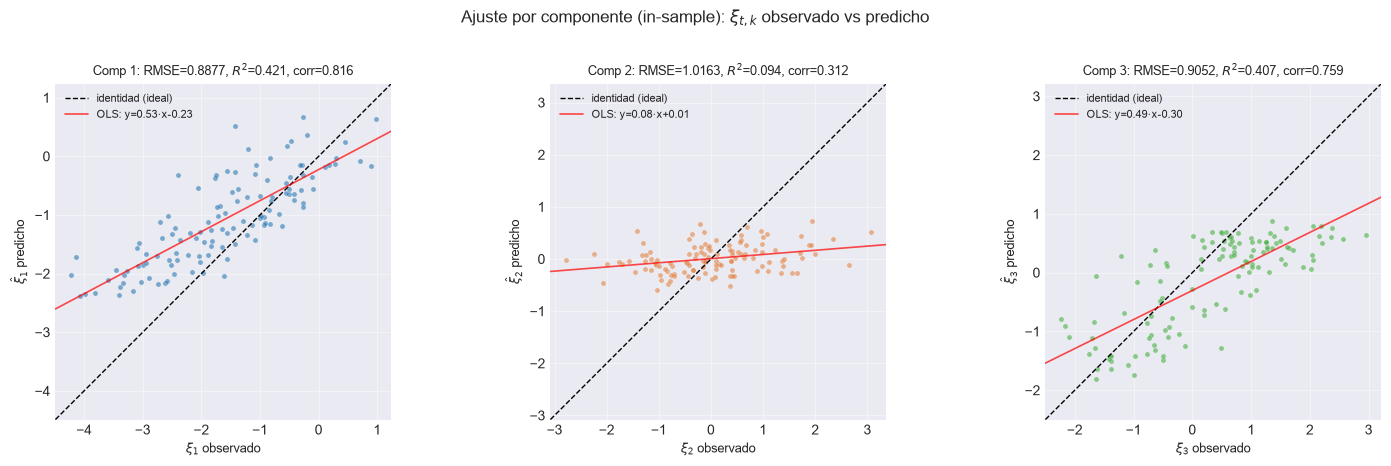

In [14]:
for M in M_OK:
    e = EST[M]
    eval_scatter = {k: {"y_obs": e["Y_obs"][~es_train, k],
                        "y_hat": e["Y_hat"][~es_train, k]}
                    for k in range(e["n_components"])}
    plot_scatter_theta(
        eval_scatter, n_components=e["n_components"],
        save_path=str(e["paths"]["out_report"] / "53_scatter_scores_test.png"))
    plt.show()

## 6. Intervalos de credibilidad sobre la curva

Extractos de la serie funcional cada `CADA` períodos, cada uno con su banda
puntual, la curva verdadera y —en gris— los datos observados, para ver de un
vistazo dónde estaba el ruido que la banda **no** tiene que cubrir.

Como la curva verdadera es la misma en todos los $M$, poner los extractos de
los distintos puntos uno debajo de otro es la comparación visual más directa
del efecto del truncamiento.

[plot_extractos_curvas] inicio (20 pasos)
  1/20 ( 5.0%) t=0.0s eta=0.1s  t=2 [train] cob=1.000 rmse=0.9484
  2/20 (10.0%) t=0.0s eta=0.1s  t=22 [train] cob=1.000 rmse=1.26
  3/20 (15.0%) t=0.0s eta=0.1s  t=42 [train] cob=0.667 rmse=1.906
  4/20 (20.0%) t=0.0s eta=0.1s  t=62 [train] cob=1.000 rmse=0.7757
  5/20 (25.0%) t=0.0s eta=0.1s  t=82 [train] cob=1.000 rmse=2.423
  6/20 (30.0%) t=0.0s eta=0.1s  t=102 [train] cob=1.000 rmse=0.7295
  7/20 (35.0%) t=0.0s eta=0.1s  t=122 [train] cob=1.000 rmse=1.217
  8/20 (40.0%) t=0.0s eta=0.1s  t=142 [train] cob=1.000 rmse=0.919
  9/20 (45.0%) t=0.1s eta=0.1s  t=162 [train] cob=1.000 rmse=0.2003
  10/20 (50.0%) t=0.1s eta=0.1s  t=182 [train] cob=1.000 rmse=0.3124
  11/20 (55.0%) t=0.1s eta=0.1s  t=202 [train] cob=1.000 rmse=0.5596
  12/20 (60.0%) t=0.1s eta=0.0s  t=222 [train] cob=1.000 rmse=0.5834
  13/20 (65.0%) t=0.1s eta=0.0s  t=242 [train] cob=1.000 rmse=1.118
  14/20 (70.0%) t=0.1s eta=0.0s  t=262 [train] cob=1.000 rmse=0.698
  15/20 (75.0%)

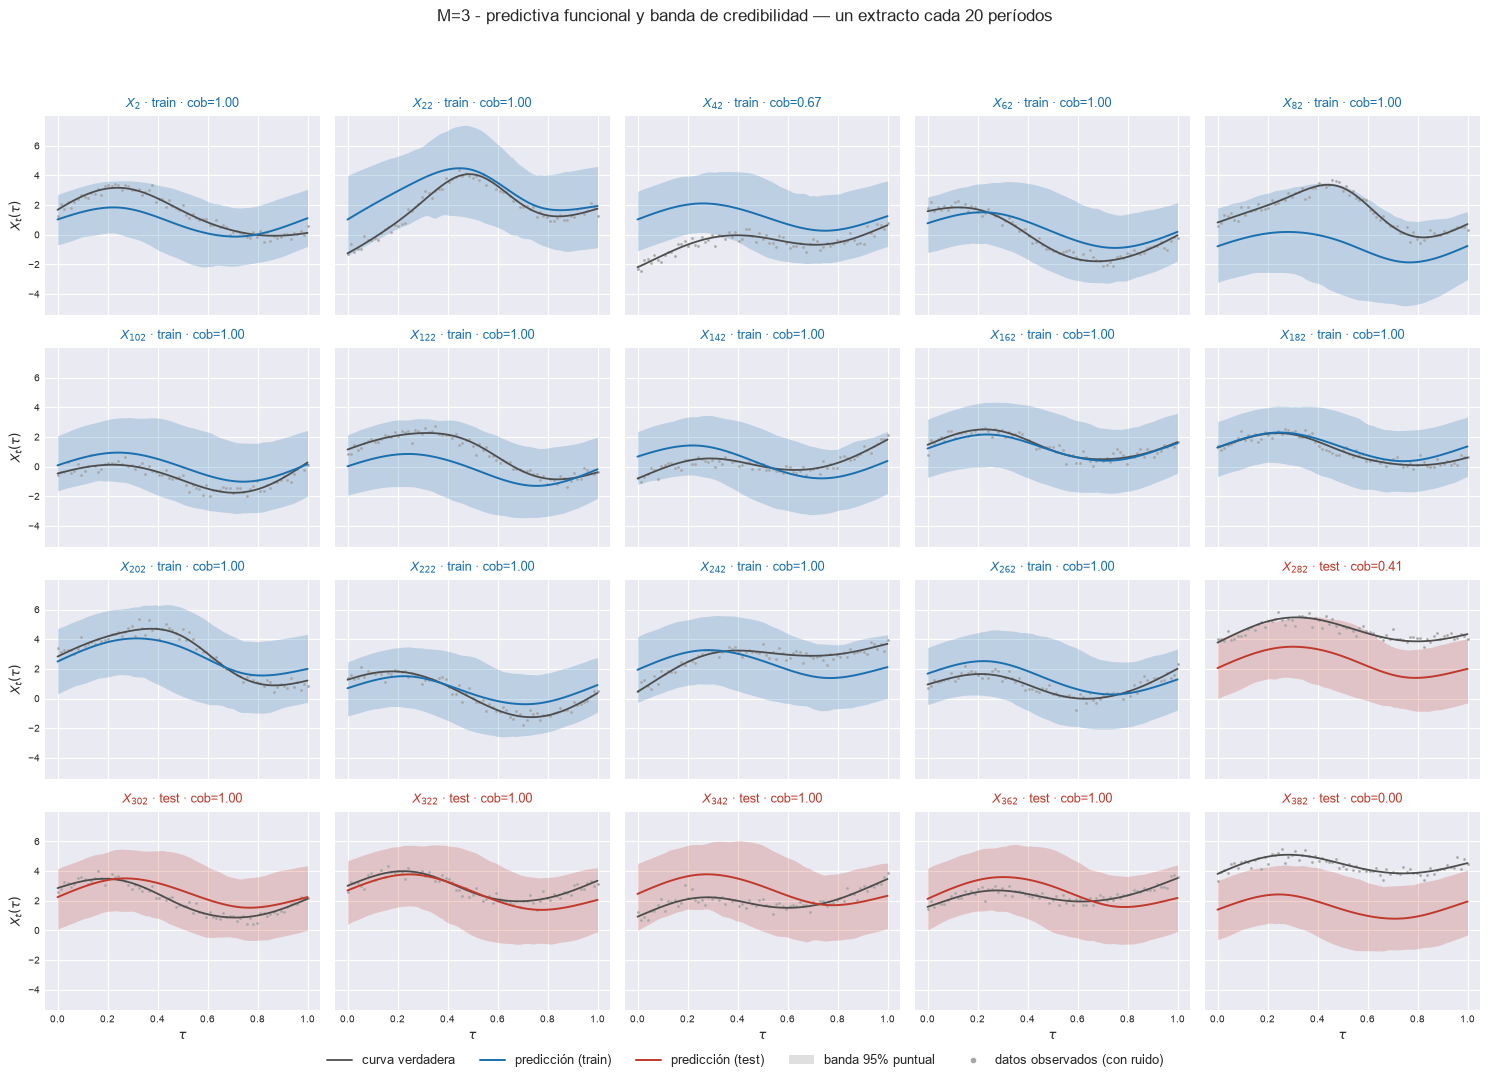

In [15]:
for M in M_OK:
    e = EST[M]
    plot_extractos_curvas(
        X_true_ev, e["X_pred"], e["li_f"], e["ls_f"], grilla, T0, t=t_orig,
        cada=CADA, n_col=5, nivel=NIVEL, X_obs=X_obs_ev,
        title=f"M={M} - predictiva funcional y banda de credibilidad",
        save_path=str(e["paths"]["out_report"] / "54_extractos_curvas.png"),
        verbose=True)
    plt.show()

[plot_extractos_curvas] inicio (7 pasos)
  1/7 (14.3%) t=0.0s eta=0.0s  t=277 [train] cob=1.000 rmse=0.2869
  2/7 (28.6%) t=0.0s eta=0.0s  t=278 [train] cob=1.000 rmse=0.854
  3/7 (42.9%) t=0.0s eta=0.0s  t=279 [train] cob=1.000 rmse=0.3725
  4/7 (57.1%) t=0.0s eta=0.0s  t=280 [train] cob=0.667 rmse=1.932
  5/7 (71.4%) t=0.1s eta=0.0s  t=281 [test] cob=1.000 rmse=0.242
  6/7 (85.7%) t=0.1s eta=0.0s  t=282 [test] cob=0.413 rmse=2.139
  7/7 (100.0%) t=0.1s eta=0.0s  t=283 [test] cob=1.000 rmse=1.081
[plot_extractos_curvas] listo: 7 pasos en 0.7s  cob media train=0.917 test=0.804 (nominal 0.95)


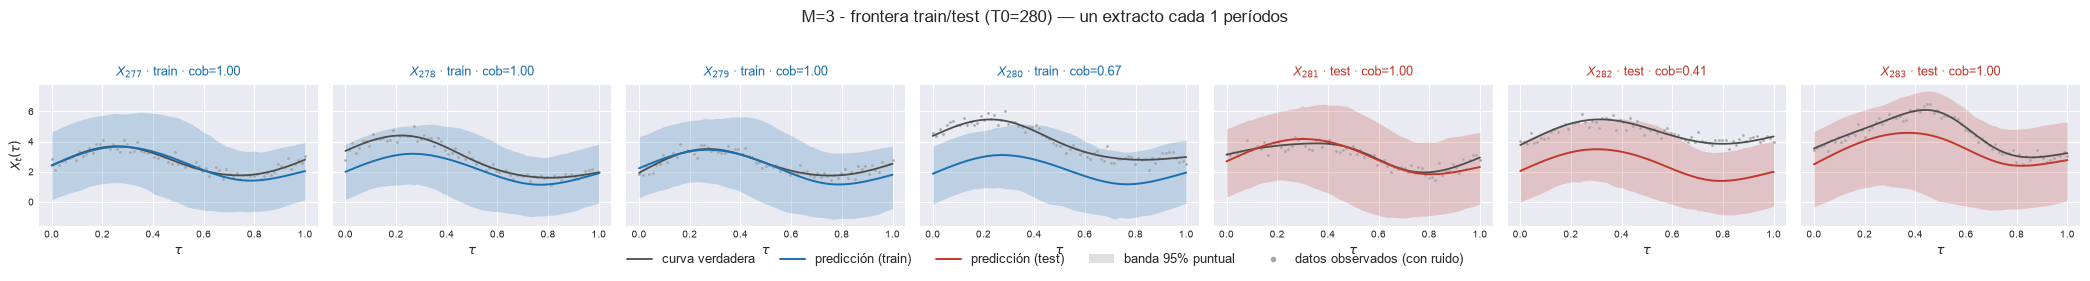

In [16]:
# Zoom sobre la frontera: los últimos orígenes de train y los primeros de test.
# Es donde se ve, curva a curva, si la banda se ensancha al salir de muestra.
i_corte = int(np.searchsorted(t_orig, T0))
sel = np.arange(max(0, i_corte - 3), min(n_orig, i_corte + 4))

for M in M_OK:
    e = EST[M]
    plot_extractos_curvas(
        X_true_ev[sel], e["X_pred"][sel], e["li_f"][sel], e["ls_f"][sel],
        grilla, T0, t=t_orig[sel], cada=1, n_col=len(sel), nivel=NIVEL,
        X_obs=X_obs_ev[sel],
        title=f"M={M} - frontera train/test (T0={T0})",
        save_path=str(e["paths"]["out_report"] / "55_extractos_frontera.png"),
        verbose=True)
    plt.show()

## 7. Ventana móvil

El modelo **no se reentrena**: lo que se desliza es la ventana de evaluación.
Cada punto agrega las métricas de $w$ orígenes consecutivos, todos a $h=1$ con
los rezagos reales. Se superponen varios anchos para que la conclusión no
dependa de un $w$ elegido a dedo; las ventanas que **cruzan** $T_0$ van
punteadas, porque su cifra mezcla dentro y fuera de muestra.

[ventana_movil_scores[FPC 1, w=20]] inicio (380 pasos)
  1/380 ( 0.3%) t=0.0s eta=8.9s  t=11 [train] rmse=0.9546
  19/380 ( 5.0%) t=0.4s eta=7.6s  t=29 [train] rmse=0.7178
  38/380 (10.0%) t=0.9s eta=7.8s  t=48 [train] rmse=0.8394
  57/380 (15.0%) t=1.2s eta=7.0s  t=67 [train] rmse=0.7038
  76/380 (20.0%) t=1.7s eta=6.6s  t=86 [train] rmse=0.8474
  95/380 (25.0%) t=2.1s eta=6.2s  t=105 [train] rmse=0.6268
  114/380 (30.0%) t=2.4s eta=5.7s  t=124 [train] rmse=0.6342
  133/380 (35.0%) t=2.8s eta=5.3s  t=143 [train] rmse=0.4937
  152/380 (40.0%) t=3.2s eta=4.9s  t=162 [train] rmse=0.6257
  171/380 (45.0%) t=3.6s eta=4.4s  t=181 [train] rmse=0.6475
  190/380 (50.0%) t=4.0s eta=4.0s  t=200 [train] rmse=0.6572
  209/380 (55.0%) t=4.4s eta=3.6s  t=219 [train] rmse=0.6587
  228/380 (60.0%) t=4.8s eta=3.2s  t=238 [train] rmse=0.7763
  247/380 (65.0%) t=5.2s eta=2.8s  t=257 [train] rmse=0.6749
  266/380 (70.0%) t=5.6s eta=2.4s  t=276 [train] rmse=0.8494
  285/380 (75.0%) t=6.0s eta=2.0s  t=295 [

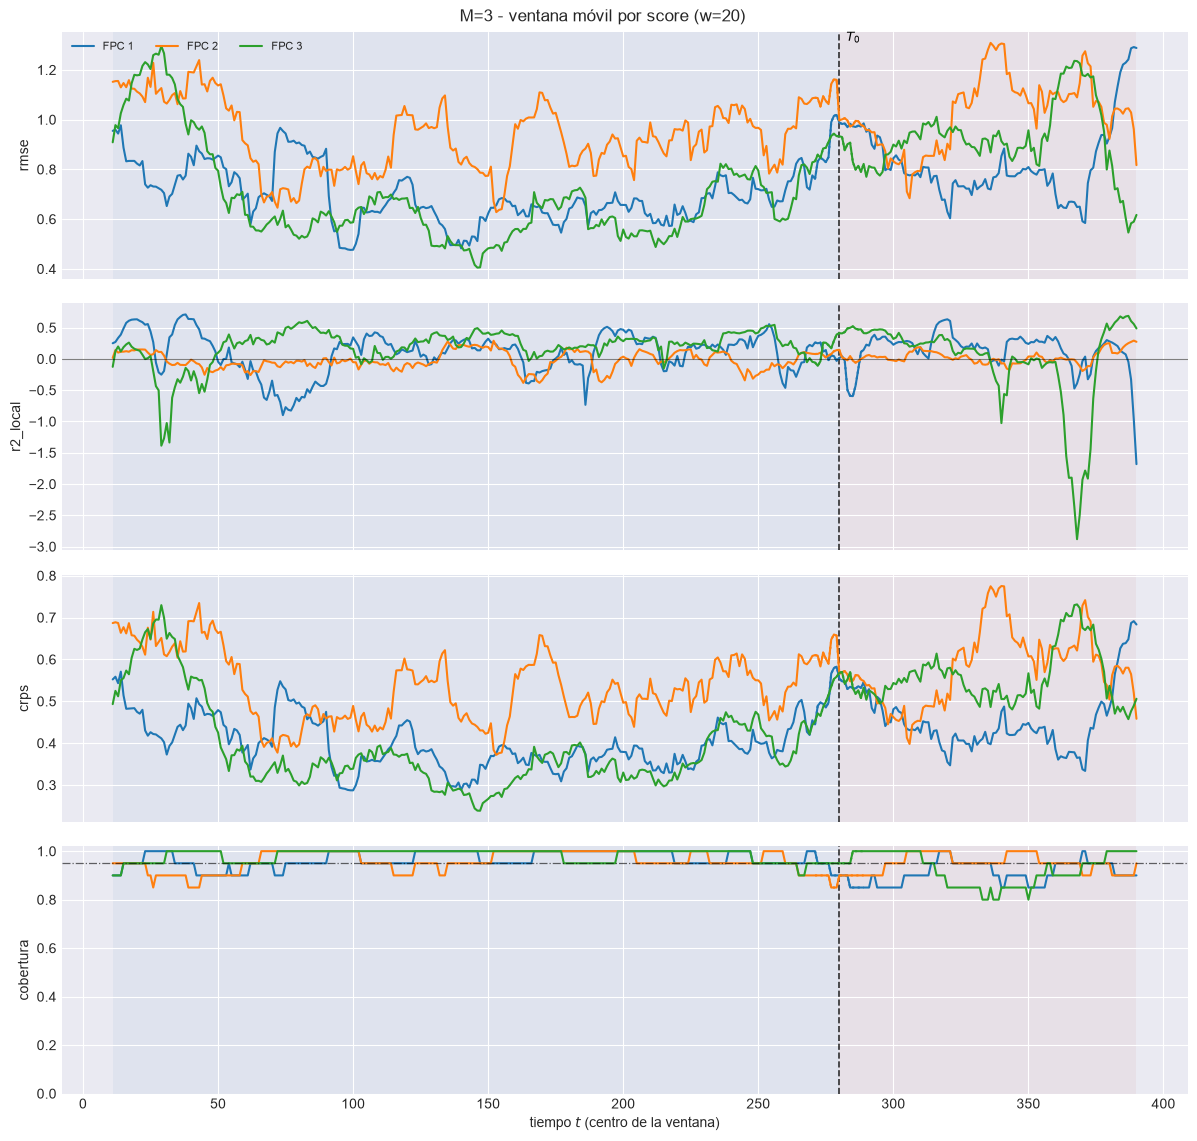

In [17]:
# `verbose` sólo en el ancho de referencia: con todos los anchos y todos los M
# la salida serían miles de líneas.
for M in M_OK:
    e = EST[M]
    etiquetas = [f"FPC {i + 1}" for i in e["component_idx"]]
    tablas_score = {
        w: ventana_movil_scores(
            e["Y_obs"], e["Y_hat"], T0_orig, w=w, muestras=e["SC_draws"],
            li=e["li_s"], ls=e["ls_s"], t_offset=N_LAGS,
            etiquetas=etiquetas, verbose=(w == W_REF))
        for w in VENTANAS_W
    }
    e["tablas_score"] = tablas_score
    tablas_score[W_REF].to_csv(
        e["paths"]["out_report"] / f"56_ventana_scores_w{W_REF}.csv", index=False)

    plot_ventana_movil(
        tablas_score[W_REF], T0, ["rmse", "r2_local", "crps", "cobertura"],
        columna_grupo="componente",
        title=f"M={M} - ventana móvil por score (w={W_REF})",
        save_path=str(e["paths"]["out_report"] / "56_ventana_scores.png"),
        verbose=True)
    plt.show()

[ventana_movil_funcional[w=20]] inicio (380 pasos)
  1/380 ( 0.3%) t=0.0s eta=2.9s  t=11 [train] mise=1.982
  19/380 ( 5.0%) t=0.0s eta=0.2s  t=29 [train] mise=1.408
  38/380 (10.0%) t=0.0s eta=0.1s  t=48 [train] mise=1.631
  57/380 (15.0%) t=0.0s eta=0.1s  t=67 [train] mise=1.056
  76/380 (20.0%) t=0.0s eta=0.1s  t=86 [train] mise=1.55
  95/380 (25.0%) t=0.0s eta=0.1s  t=105 [train] mise=0.8854
  114/380 (30.0%) t=0.0s eta=0.1s  t=124 [train] mise=0.9646
  133/380 (35.0%) t=0.0s eta=0.1s  t=143 [train] mise=0.6268
  152/380 (40.0%) t=0.0s eta=0.1s  t=162 [train] mise=1.001
  171/380 (45.0%) t=0.0s eta=0.1s  t=181 [train] mise=0.968
  190/380 (50.0%) t=0.0s eta=0.0s  t=200 [train] mise=0.9596
  209/380 (55.0%) t=0.0s eta=0.0s  t=219 [train] mise=1.042
  228/380 (60.0%) t=0.1s eta=0.0s  t=238 [train] mise=1.403
  247/380 (65.0%) t=0.1s eta=0.0s  t=257 [train] mise=0.9925
  266/380 (70.0%) t=0.1s eta=0.0s  t=276 [train] mise=1.645
  285/380 (75.0%) t=0.1s eta=0.0s  t=295 [test] mise=1.87

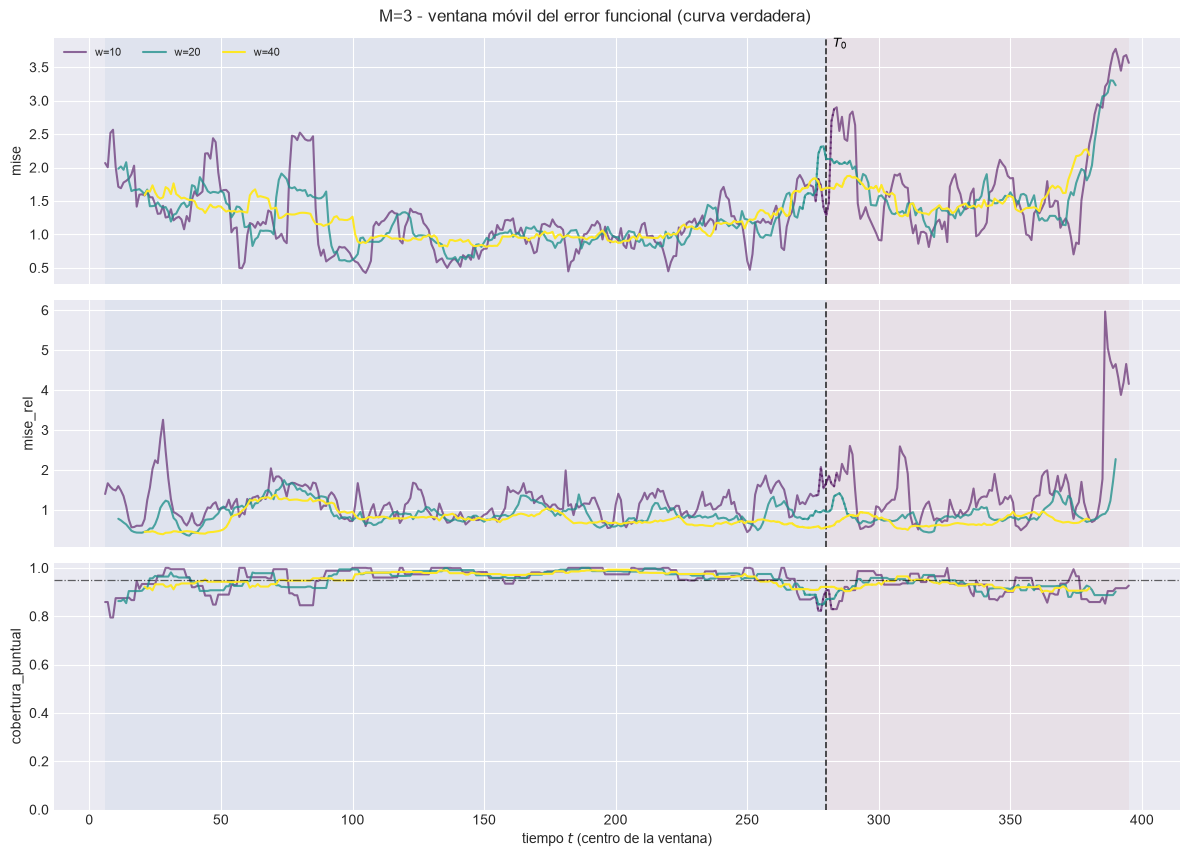

In [18]:
for M in M_OK:
    e = EST[M]
    tablas_fun = {
        w: ventana_movil_funcional(X_true_ev, e["X_pred"], grilla, T0_orig, w=w,
                                   li=e["li_f"], ls=e["ls_f"], t_offset=N_LAGS,
                                   verbose=(w == W_REF))
        for w in VENTANAS_W
    }
    e["tablas_fun"] = tablas_fun
    tablas_fun[W_REF].to_csv(
        e["paths"]["out_report"] / f"57_ventana_funcional_w{W_REF}.csv", index=False)

    plot_ventana_movil(
        tablas_fun[W_REF], T0, ["mise", "mise_rel", "cobertura_puntual"],
        tablas_por_w=tablas_fun,
        title=f"M={M} - ventana móvil del error funcional (curva verdadera)",
        save_path=str(e["paths"]["out_report"] / "57_ventana_funcional.png"),
        verbose=True)
    plt.show()

In [19]:
# Lectura numérica del salto en T0, excluyendo las ventanas que lo cruzan.
for M in M_OK:
    e = EST[M]
    print(f"── M={M} ──")
    print(f"{'w':>4}  {'MISE train':>11}  {'MISE test':>11}  {'salto':>7}")
    print(f"{'-'*4}  {'-'*11}  {'-'*11}  {'-'*7}")
    saltos = {}
    for w in VENTANAS_W:
        t_ = e["tablas_fun"][w]
        limpio = t_[~t_["cruza_T0"]]
        a = limpio.loc[limpio.bloque == "train", "mise"].mean()
        b = limpio.loc[limpio.bloque == "test",  "mise"].mean()
        saltos[w] = float(b / a)
        print(f"{w:>4}  {a:>11.6f}  {b:>11.6f}  {b/a:>6.2f}x")
    e["saltos_T0"] = saltos

── M=3 ──
   w   MISE train    MISE test    salto
----  -----------  -----------  -------
  10     1.175820     1.727523    1.47x
  20     1.150828     1.612177    1.40x
  40     1.127292     1.530012    1.36x


## 8. Calibración

Bajo calibración perfecta el PIT es uniforme. La **forma** dice qué falla: una
U indica bandas demasiado angostas, una campana demasiado anchas, y una
pendiente un sesgo del centro. Contrastar train contra test separa el desajuste
del modelo de la pérdida de calibración fuera de muestra.

[plot_calibracion_pit] inicio (3 pasos)
  1/3 (33.3%) t=0.0s eta=0.0s  FPC 1  train: media=0.497 desv_max=0.290 n=279  |  test: media=0.333 desv_max=1.083 n=120
  2/3 (66.7%) t=0.0s eta=0.0s  FPC 2  train: media=0.495 desv_max=0.326 n=279  |  test: media=0.507 desv_max=0.417 n=120
  3/3 (100.0%) t=0.0s eta=0.0s  FPC 3  train: media=0.498 desv_max=0.326 n=279  |  test: media=0.627 desv_max=0.667 n=120
[plot_calibracion_pit] listo: 3 pasos en 0.2s  -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\simulaciones\escenario_C_r01_m03\58_pit.png


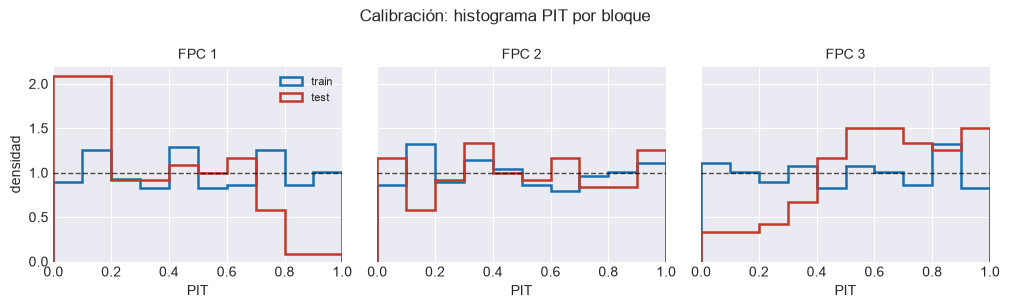

── M=3 ──
  FPC 1:  train KS=0.025 (aproximadamente uniforme)   test KS=0.240 (aproximadamente uniforme)
  FPC 2:  train KS=0.034 (aproximadamente uniforme)   test KS=0.038 (aproximadamente uniforme)
  FPC 3:  train KS=0.025 (aproximadamente uniforme)   test KS=0.236 (aproximadamente uniforme)


In [20]:
for M in M_OK:
    e = EST[M]
    ci = e["component_idx"]
    pit_tr = {f"FPC {ci[k]+1}": pit_muestral(e["Y_obs"][es_train, k],
                                             e["SC_draws"][:, es_train, k])
              for k in range(e["n_components"])}
    pit_te = {f"FPC {ci[k]+1}": pit_muestral(e["Y_obs"][~es_train, k],
                                             e["SC_draws"][:, ~es_train, k])
              for k in range(e["n_components"])}
    e["pit_tr"], e["pit_te"] = pit_tr, pit_te

    plot_calibracion_pit(pit_tr, pit_te,
                         save_path=str(e["paths"]["out_report"] / "58_pit.png"),
                         verbose=True)
    plt.show()

    print(f"── M={M} ──")
    for nombre in pit_tr:
        d_tr, d_te = diagnostico_pit(pit_tr[nombre]), diagnostico_pit(pit_te[nombre])
        print(f"  {nombre}:  train KS={d_tr['ks']:.3f} ({d_tr['forma']})   "
              f"test KS={d_te['ks']:.3f} ({d_te['forma']})")
    e["pit_ks_test_max"] = float(max(diagnostico_pit(v)["ks"]
                                     for v in pit_te.values()))

## 9. Comparación con las líneas base

In [21]:
for M in M_OK:
    e = EST[M]
    bl = e["paths"]["out_report"] / "30_baselines_test.csv"
    rmse_psbp = e["met_df"].loc["test", "RMSE"].mean()
    print(f"── M={M} ──  RMSE promedio en scores, PSBP-FD (test): {rmse_psbp:.4f}")

    if bl.exists():
        baselines_df = pd.read_csv(bl, index_col=0)
        display(baselines_df.style.format("{:.4f}", na_rep="-")
                .set_caption(f"M={M} - líneas base sobre el bloque de prueba (h=1)"))
        if "RMSE_scores_prom" in baselines_df.columns:
            for modelo, fila in baselines_df.iterrows():
                marca = ("OK PSBP mejor" if rmse_psbp < fila["RMSE_scores_prom"]
                         else "X baseline mejor")
                print(f"    vs {modelo:24s} RMSE={fila['RMSE_scores_prom']:.4f}"
                      f"  -> {marca}")
    else:
        print(f"    ! falta {bl.name} - ejecuta 19_01 §6 para este M.")

── M=3 ──  RMSE promedio en scores, PSBP-FD (test): 0.9364


,n_test,RMSE_fpc1,RMSE_fpc2,RMSE_fpc3,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,,,
media_incondicional,120.0000,2.0085,1.0681,1.2184,1.4317,-0.6801,7.7555,2.7849
persistencia_lag1,120.0000,0.6912,1.2538,0.9738,0.9729,0.1945,1.3327,1.1544


    vs media_incondicional      RMSE=1.4317  -> OK PSBP mejor
    vs persistencia_lag1        RMSE=0.9729  -> OK PSBP mejor


### 9.1 Calibración condicional por magnitud de la interacción

**La sección propia de este escenario.** Aquí no hay multimodalidad —la ley
condicional es unimodal— de modo que el coeficiente de Sarle no viene al caso.
Lo que sí hay es una **media condicional que se aparta de la lineal**, y el
apartamiento no es uniforme: depende de $q_t = \lVert\text{término
cuadrático}\rVert$, que `18_01 §2.4` persistió por cuartiles.

La pregunta: **¿el modelo se aparta del FAR(1) donde debe?** Si está recuperando
el mecanismo, en el cuartil alto de $q_t$ su predicción debe diferir más de la
del predictor lineal, y su banda debe seguir cubriendo. Un modelo que ignora la
interacción tendrá el mismo error en los cuatro cuartiles; uno que la recupera,
una mejora concentrada en el cuartil alto.

La segunda mitad de la sección es la cobertura condicional por el mismo estrato:
un modelo puede acertar la media y perder la calibración justo donde la
dinámica es más no lineal, y la cobertura marginal lo esconde.


In [22]:
from model_psbp_fd.fit import estratos_por_cuantil

filas_q, filas_cob = [], []

for M in M_OK:
    e = EST[M]

    est = pd.read_csv(e["paths"]["out_report"] / "10_estado_tendencia.csv")
    assert len(est) == T, f"[M={M}] 10_estado_tendencia.csv tiene {len(est)} filas y T={T}."
    est_ev = est.iloc[N_LAGS:].reset_index(drop=True)
    assert np.array_equal(est_ev["t"].to_numpy(), t_orig), \
        "El CSV de estado no está alineado con la serie de orígenes."

    estratos = est_ev["estrato_q"].to_numpy().astype(int)
    etiquetas = ["q1 (baja)", "q2", "q3", "q4 (alta)"][:len(np.unique(estratos))]

    # -- error del modelo por cuartil de interacción -------------------------
    for u, etq in zip(np.unique(estratos), etiquetas):
        m = estratos == u
        filas_q.append({
            "M": M, "estrato": etq, "n": int(m.sum()),
            "q_medio": float(est_ev.loc[m, "q_interaccion"].mean()),
            "MISE": mise(X_true_ev[m], e["X_pred"][m], grilla),
            "MISE_truncamiento": mise(X_true_ev[m], e["X_proj"][m], grilla),
            "frac_test": float((est_ev.loc[m, "bloque"] == "test").mean()),
        })

    # -- cobertura condicional por el mismo estrato -------------------------
    cob_s = cobertura_condicional(
        e["Y_obs"][:, 0], e["li_s"][:, 0], e["ls_s"][:, 0], estratos,
        etiquetas=etiquetas, muestras=e["SC_draws"][:, :, 0])
    for f in cob_s:
        filas_cob.append({"M": M, "objeto": "score 1", **f})
    cob_f = cobertura_condicional(
        X_true_ev, e["li_f"], e["ls_f"], estratos, etiquetas=etiquetas, tau=grilla)
    for f in cob_f:
        filas_cob.append({"M": M, "objeto": "curva", **f})

INTERQ = pd.DataFrame(filas_q)
COBC   = pd.DataFrame(filas_cob)

for M in M_OK:
    INTERQ[INTERQ.M == M].to_csv(
        EST[M]["paths"]["out_report"] / "61_error_por_interaccion.csv", index=False)
    COBC[COBC.M == M].to_csv(
        EST[M]["paths"]["out_report"] / "62_cobertura_condicional.csv", index=False)

display(INTERQ.style.format({"q_medio": "{:.4f}", "MISE": "{:.6f}",
                             "MISE_truncamiento": "{:.6f}", "frac_test": "{:.1%}"})
        .set_caption("Error por cuartil de la magnitud de la interacción"))
display(COBC.style.format({"cobertura": "{:.3f}", "ancho_medio": "{:.4f}",
                           "desvio": "{:+.3f}", "crps": "{:.4f}",
                           "energy": "{:.4f}"}, na_rep="-")
        .set_caption(f"Cobertura condicional al {NIVEL:.0%} por cuartil de interacción"))

print("Lectura:")
for M in M_OK:
    d = INTERQ[INTERQ.M == M].set_index("estrato")
    if {"q1 (baja)", "q4 (alta)"} <= set(d.index):
        r = d.loc["q4 (alta)", "MISE"] / d.loc["q1 (baja)", "MISE"]
        print(f"  M={M}: MISE(q alto)/MISE(q bajo) = {r:.3f}")
print("\nUna razón cercana a 1 dice que el modelo se comporta igual donde la "
      "interacción es\nfuerte y donde es débil: no la está usando. El contraste "
      "definitivo es contra el\nmismo cociente del VAR, en el _05.")


,M,estrato,n,q_medio,MISE,MISE_truncamiento,frac_test
0,3,q1 (baja),100,0.1026,1.181885,0.008945,25.0%
1,3,q2,99,0.2615,1.130882,0.008947,24.2%
2,3,q3,100,0.3508,1.322016,0.008827,23.0%
3,3,q4 (alta),100,1.0014,1.851779,0.013793,48.0%


,M,objeto,estrato,n,cobertura,ancho_medio,desvio,crps
0,3,score 1,q1 (baja),100,0.930,2.9110,-0.017,0.3985
1,3,score 1,q2,99,0.960,2.8816,+0.012,0.3846
2,3,score 1,q3,100,0.950,2.8448,+0.003,0.4306
3,3,score 1,q4 (alta),100,0.950,3.6837,+0.003,0.4885
4,3,curva,q1 (baja),100,0.942,4.3652,-0.005,-
5,3,curva,q2,99,0.953,4.3214,+0.006,-
6,3,curva,q3,100,0.937,4.3200,-0.010,-
7,3,curva,q4 (alta),100,0.955,5.4873,+0.008,-


Lectura:
  M=3: MISE(q alto)/MISE(q bajo) = 1.567

Una razón cercana a 1 dice que el modelo se comporta igual donde la interacción es
fuerte y donde es débil: no la está usando. El contraste definitivo es contra el
mismo cociente del VAR, en el _05.


## 10. Resumen por punto del barrido

In [23]:
for M in M_OK:
    e = EST[M]
    resumen = {
        "experiment_id": e["eid"],
        "M_fpca": e["M_fpca"], "K_base": e["K"],
        "var_explicada": round(e["var_explicada"], 6),
        "objetivo_evaluacion": OBJETIVO,
        "modo_residuo": MODO_RESIDUO,
        "nivel": NIVEL,
        "S_scores": e["S_total"], "S_funcional": e["S_funcional"],
        "rmse_scores_train": float(e["met_df"].loc["train", "RMSE"].mean()),
        "rmse_scores_test":  float(e["met_df"].loc["test", "RMSE"].mean()),
        "mise_train": float(e["fun_df"].loc["train", "MISE"]),
        "mise_test":  float(e["fun_df"].loc["test", "MISE"]),
        "mise_truncamiento_test": float(e["fun_df"].loc["test", "MISE_truncamiento"]),
        "cobertura_puntual_test": float(
            e["fun_df"].loc["test", f"Cob{int(NIVEL*100)}_puntual"]),
    }
    pd.Series(resumen).to_csv(e["paths"]["out_report"] / "59_resumen.csv",
                              header=False)
    e["resumen"] = resumen
    print(f"── M={M} ──")
    for k, v in resumen.items():
        print(f"  {k:26s}: {v}")
    print(f"  figuras y tablas en {e['paths']['out_report']}")

── M=3 ──
  experiment_id             : escenario_C_r01_m03
  M_fpca                    : 3
  K_base                    : 7
  var_explicada             : 0.995513
  objetivo_evaluacion       : curva_verdadera
  modo_residuo              : ninguno
  nivel                     : 0.95
  S_scores                  : 45000
  S_funcional               : 500
  rmse_scores_train         : 0.7977293246650018
  rmse_scores_test          : 0.9363916773667201
  mise_train                : 1.1971369676562138
  mise_test                 : 1.77936833873395
  mise_truncamiento_test    : 0.011268984283280794
  cobertura_puntual_test    : 0.9256666666666666
  figuras y tablas en C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\simulaciones\escenario_C_r01_m03


## 11. El barrido: comparación entre los $M$

Aquí es donde el notebook responde `§03_06`. Todo lo anterior describe cada
punto; esto los pone en el mismo eje.

**La lectura correcta no es "¿baja el MISE al subir $M$?".** El MISE de
truncamiento —el error de proyectar la curva verdadera sobre las $M$
autofunciones, sin modelo alguno— baja siempre con $M$: es aritmética. La
pregunta es si el error del **modelo** baja tanto como su propio piso. Por eso
la cifra central es la **razón `MISE / MISE_truncamiento`**: cuánto agrega el
modelo por encima de lo que la representación ya le regala.

| Si al subir $M$… | Lectura |
|---|---|
| MISE baja y la razón se mantiene | $M$ aporta información y el modelo la aprovecha |
| MISE baja pero la razón **sube** | la ganancia es toda de la representación; el modelo empeora relativo a su piso |
| MISE **sube** | las componentes nuevas son ruido neto — la hipótesis de la Etapa D |

Se acompaña de la calibración (cobertura y ancho de banda) porque un modelo
puede conservar el MISE y perder la cobertura, que es el modo de fallo que la
métrica puntual no ve.

### La predicción propia del Escenario B, y es la opuesta a la de la corrida 20

En la corrida 20 la hipótesis del barrido era que **subir $M$ deteriora**:
componentes de varianza baja que el estandarizador amplifica y que entran a la
regresión probit de los pesos como ruido. Aquí hay un efecto **de signo
contrario y anterior a ése**, y domina en el primer tramo del barrido:

> con $M=1$ el modelo **no observa la dirección que gobierna la conmutación**
> —carga sobre la segunda componente, ver `10_alineacion_conmutacion.csv`— y
> por tanto no puede recuperar nada: debe comportarse como el FAR(1). Con
> $M=2$ la observa.

De modo que la predicción es un **salto** entre $M=1$ y $M=2$, no una
degradación suave, y después de $M=2$ vuelve a regir la hipótesis de la
corrida 20. Un barrido plano entre 1 y 2 sería evidencia de que el modelo no
está usando la covariable aunque la tenga — un hallazgo negativo distinto y más
fuerte que el de la corrida 20.


In [24]:
filas = []
for M in M_OK:
    e = EST[M]
    for bloque in ("train", "test"):
        f = e["fun_df"].loc[bloque]
        s = e["met_df"].loc[bloque]
        filas.append({
            "M": M, "bloque": bloque,
            "p_covariables": len(e["cov_names"]),
            "var_explicada": e["var_explicada"],
            "RMSE_scores": float(s["RMSE"].mean()),
            "R2_scores":   float(s["R2"].mean()),
            "CRPS":        float(s["CRPS"].mean()),
            "Cob_scores":  float(s[f"Cob{int(NIVEL*100)}"].mean()),
            "Ancho_scores": float(s["Ancho"].mean()),
            "PIT_ks_max":  float(s["PIT_ks"].max()),
            "MISE":        float(f["MISE"]),
            "MISE_truncamiento": float(f["MISE_truncamiento"]),
            "razon_MISE_piso":   float(f["MISE"] / f["MISE_truncamiento"]),
            "RMSE_f":      float(f["RMSE_f"]),
            "energy":      float(f["energy"]),
            "Cob_puntual": float(f[f"Cob{int(NIVEL*100)}_puntual"]),
            "ancho_funcional": float(f["ancho_medio"]),
        })

barrido_df = pd.DataFrame(filas).set_index(["bloque", "M"]).sort_index()
barrido_df.to_csv(PATH_BARRIDO / "85_metricas_por_M.csv")

_fmt = {"var_explicada": "{:.4%}", "RMSE_scores": "{:.4f}", "R2_scores": "{:.4f}",
        "CRPS": "{:.4f}", "Cob_scores": "{:.4f}", "Ancho_scores": "{:.4f}",
        "PIT_ks_max": "{:.4f}", "MISE": "{:.6f}", "MISE_truncamiento": "{:.6f}",
        "razon_MISE_piso": "{:.3f}", "RMSE_f": "{:.6f}", "energy": "{:.4f}",
        "Cob_puntual": "{:.4f}", "ancho_funcional": "{:.4f}"}
display(barrido_df.style.format(_fmt)
        .background_gradient(subset=["MISE"], cmap="RdYlGn_r")
        .background_gradient(subset=["razon_MISE_piso"], cmap="RdYlGn_r")
        .background_gradient(subset=["Cob_puntual"], cmap="RdYlGn",
                             vmin=0.80, vmax=1.0)
        .set_caption("Métricas del PSBPM-FD a lo largo del barrido en M · "
                     "MISE contra la curva VERDADERA"))

,,p_covariables,var_explicada,RMSE_scores,R2_scores,CRPS,Cob_scores,Ancho_scores,PIT_ks_max,MISE,MISE_truncamiento,razon_MISE_piso,RMSE_f,energy,Cob_puntual,ancho_funcional
bloque,M,,,,,,,,,,,,,,,
test,3,3,99.5513%,0.9364,0.3072,0.5314,0.9306,3.7359,0.2397,1.779368,0.011269,157.900,1.333930,6.8580,0.9257,5.1164
train,3,3,99.5513%,0.7977,0.3533,0.4458,0.9665,3.2124,0.0339,1.197137,0.009642,124.164,1.094138,5.8642,0.9557,4.4041


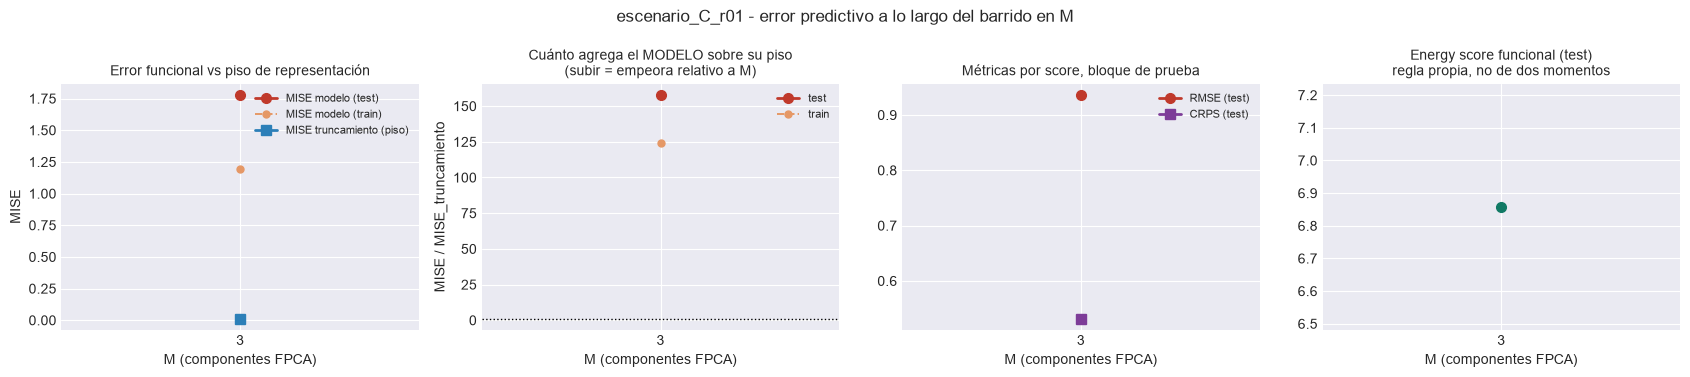

In [25]:
# Figura 1 del barrido: error. Panel izquierdo con MISE del modelo y su piso de
# truncamiento en el MISMO eje —es la comparación que decide—, y el resto con
# las métricas de score.
te = barrido_df.loc["test"]
tr = barrido_df.loc["train"]
_Ms = list(te.index)

fig, axes = plt.subplots(1, 4, figsize=(17, 3.8))

ax = axes[0]
ax.plot(_Ms, te["MISE"], "o-", lw=2, ms=7, color="#c0392b", label="MISE modelo (test)")
ax.plot(_Ms, tr["MISE"], "o--", lw=1.4, ms=5, color="#e59866", label="MISE modelo (train)")
ax.plot(_Ms, te["MISE_truncamiento"], "s-", lw=2, ms=7, color="#2c7fb8",
        label="MISE truncamiento (piso)")
ax.set_ylabel("MISE"); ax.set_title("Error funcional vs piso de representación", fontsize=10)
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(_Ms, te["razon_MISE_piso"], "o-", lw=2, ms=7, color="#c0392b", label="test")
ax.plot(_Ms, tr["razon_MISE_piso"], "o--", lw=1.4, ms=5, color="#e59866", label="train")
ax.axhline(1.0, color="k", ls=":", lw=1)
ax.set_ylabel("MISE / MISE_truncamiento")
ax.set_title("Cuánto agrega el MODELO sobre su piso\n(subir = empeora relativo a M)",
             fontsize=10)
ax.legend(fontsize=8)

ax = axes[2]
ax.plot(_Ms, te["RMSE_scores"], "o-", lw=2, ms=7, color="#c0392b", label="RMSE (test)")
ax.plot(_Ms, te["CRPS"], "s-", lw=2, ms=7, color="#7d3c98", label="CRPS (test)")
ax.set_title("Métricas por score, bloque de prueba", fontsize=10)
ax.legend(fontsize=8)

ax = axes[3]
ax.plot(_Ms, te["energy"], "o-", lw=2, ms=7, color="#117a65")
ax.set_title("Energy score funcional (test)\nregla propia, no de dos momentos",
             fontsize=10)

for ax in axes:
    ax.set_xticks(_Ms); ax.set_xlabel("M (componentes FPCA)")
fig.suptitle(f"{EXPERIMENT_BASE} - error predictivo a lo largo del barrido en M",
             fontsize=12)
fig.tight_layout()
fig.savefig(PATH_BARRIDO / "86_error_vs_M.png", dpi=150, bbox_inches="tight")
plt.show()

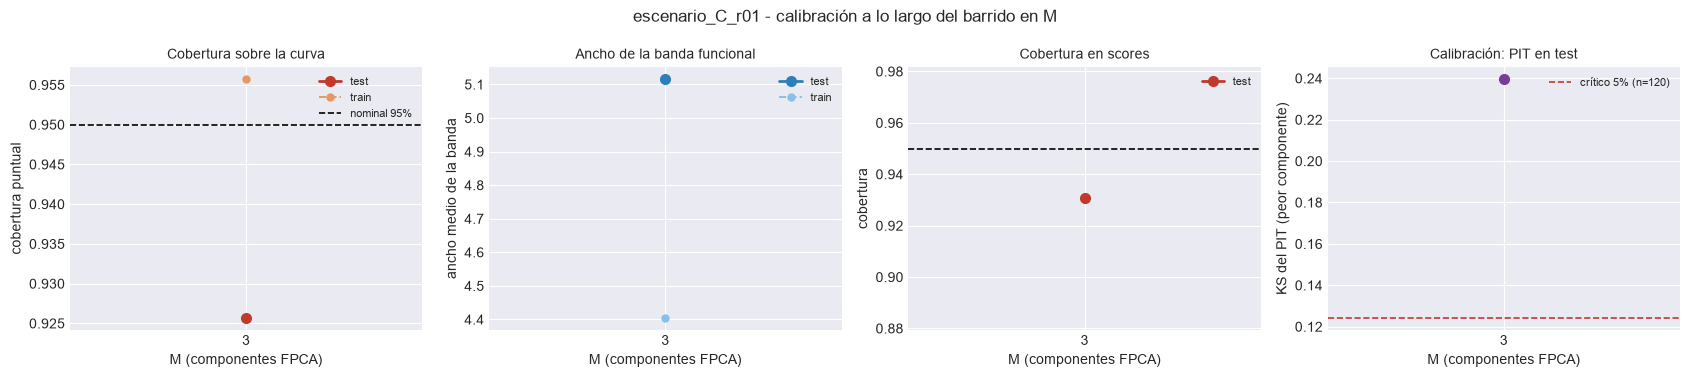

In [26]:
# Figura 2 del barrido: calibración. Un modelo puede conservar el MISE y perder
# la cobertura; ésa es la parte que la métrica puntual no ve.
fig, axes = plt.subplots(1, 4, figsize=(17, 3.8))

ax = axes[0]
ax.plot(_Ms, te["Cob_puntual"], "o-", lw=2, ms=7, color="#c0392b", label="test")
ax.plot(_Ms, tr["Cob_puntual"], "o--", lw=1.4, ms=5, color="#e59866", label="train")
ax.axhline(NIVEL, color="k", ls="--", lw=1.2, label=f"nominal {NIVEL:.0%}")
ax.set_ylabel("cobertura puntual")
ax.set_title("Cobertura sobre la curva", fontsize=10); ax.legend(fontsize=8)

ax = axes[1]
ax.plot(_Ms, te["ancho_funcional"], "o-", lw=2, ms=7, color="#2c7fb8", label="test")
ax.plot(_Ms, tr["ancho_funcional"], "o--", lw=1.4, ms=5, color="#85c1e9", label="train")
ax.set_ylabel("ancho medio de la banda")
ax.set_title("Ancho de la banda funcional", fontsize=10); ax.legend(fontsize=8)

ax = axes[2]
ax.plot(_Ms, te["Cob_scores"], "o-", lw=2, ms=7, color="#c0392b", label="test")
ax.axhline(NIVEL, color="k", ls="--", lw=1.2)
ax.set_ylabel("cobertura"); ax.set_title("Cobertura en scores", fontsize=10)
ax.legend(fontsize=8)

ax = axes[3]
ax.plot(_Ms, te["PIT_ks_max"], "o-", lw=2, ms=7, color="#7d3c98")
# Crítico KS al 5% con n = nº de orígenes de prueba. Es orientativo: los draws
# no son independientes entre orígenes.
_ncrit = int((~es_train).sum())
ax.axhline(1.36 / np.sqrt(_ncrit), color="#c0392b", ls="--", lw=1.2,
           label=f"crítico 5% (n={_ncrit})")
ax.set_ylabel("KS del PIT (peor componente)")
ax.set_title("Calibración: PIT en test", fontsize=10); ax.legend(fontsize=8)

for ax in axes:
    ax.set_xticks(_Ms); ax.set_xlabel("M (componentes FPCA)")
fig.suptitle(f"{EXPERIMENT_BASE} - calibración a lo largo del barrido en M",
             fontsize=12)
fig.tight_layout()
fig.savefig(PATH_BARRIDO / "87_calibracion_vs_M.png", dpi=150, bbox_inches="tight")
plt.show()

[plot_ventana_movil] inicio (2 pasos)
  1/2 (50.0%) t=0.0s eta=0.0s  mise: w=20 train=1.051  w=20 test=1.466
  2/2 (100.0%) t=0.0s eta=0.0s  cobertura_puntual: w=20 train=0.972  w=20 test=0.9267
[plot_ventana_movil] listo: 2 pasos en 0.5s  -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\simulaciones\escenario_C_r01_barrido_M\88_ventana_funcional_por_M.png


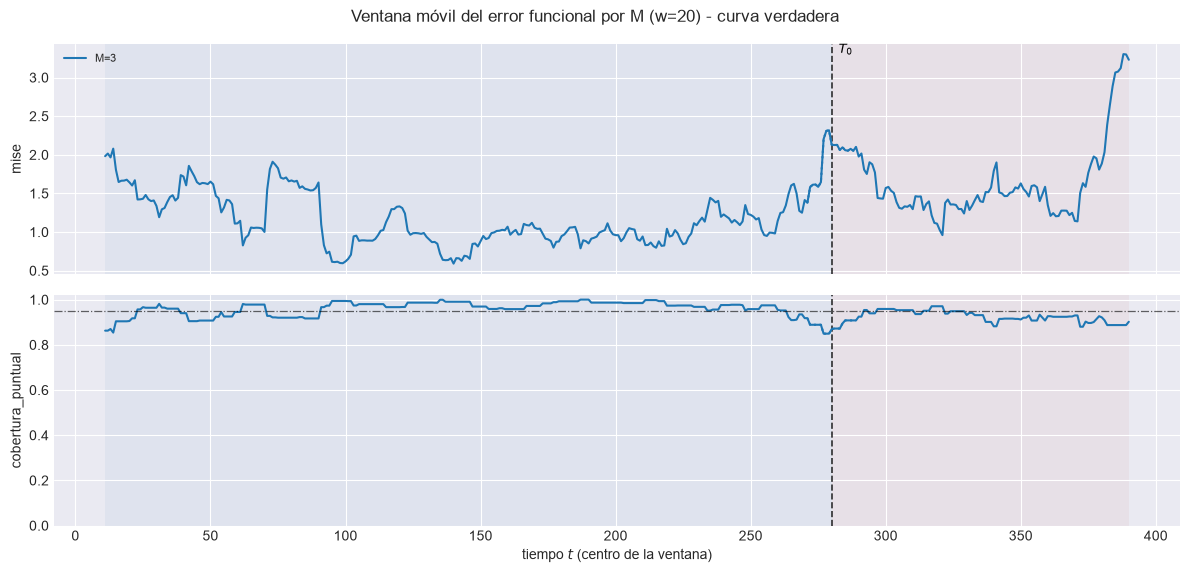

[plot_ventana_movil] inicio (3 pasos)
  1/3 (33.3%) t=0.0s eta=0.0s  rmse: w=20 train=0.6743  w=20 test=0.7833
  2/3 (66.7%) t=0.0s eta=0.0s  crps: w=20 train=0.3864  w=20 test=0.4315
  3/3 (100.0%) t=0.0s eta=0.0s  cobertura: w=20 train=0.95  w=20 test=0.9
[plot_ventana_movil] listo: 3 pasos en 0.3s  -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\simulaciones\escenario_C_r01_barrido_M\88_ventana_scores_fpc1_por_M.png


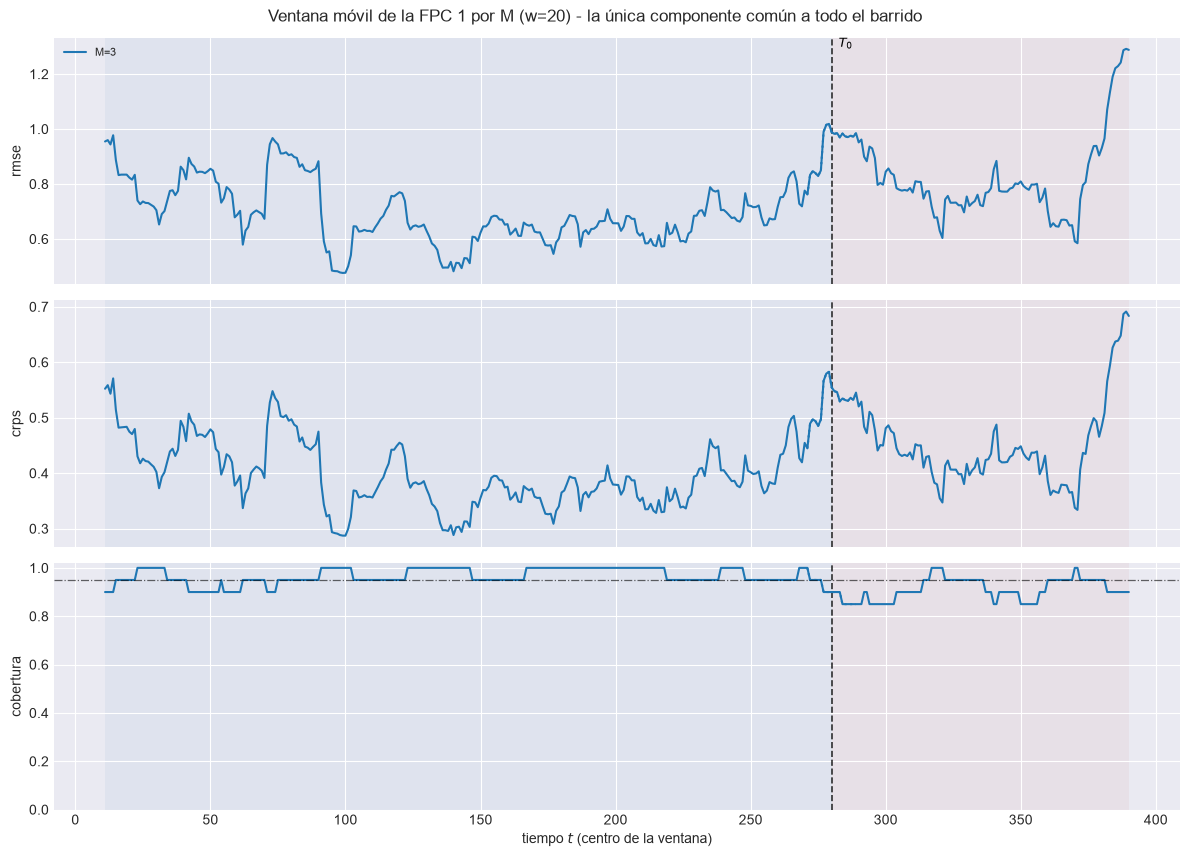

In [27]:
# Figura 3 del barrido: la ventana móvil de todos los M en el mismo eje. Es la
# misma serie de orígenes en los tres, así que las curvas son comparables punto
# a punto; lo que se busca es si la separación entre M aparece en todo el
# recorrido o sólo después de T0.
partes = []
for M in M_OK:
    t_ = EST[M]["tablas_fun"][W_REF].copy()
    t_["M"] = f"M={M}"
    partes.append(t_)
ventana_M = pd.concat(partes, ignore_index=True)
ventana_M.attrs["w"] = W_REF
ventana_M.to_csv(PATH_BARRIDO / f"88_ventana_funcional_por_M_w{W_REF}.csv",
                 index=False)

plot_ventana_movil(
    ventana_M, T0, ["mise", "cobertura_puntual"], columna_grupo="M",
    title=f"Ventana móvil del error funcional por M (w={W_REF}) - curva verdadera",
    save_path=str(PATH_BARRIDO / "88_ventana_funcional_por_M.png"),
    verbose=True)
plt.show()

# Y la misma comparación en scores, restringida a la PRIMERA componente FPCA,
# que es la única presente en todos los puntos del barrido. Comparar el
# promedio sobre componentes mezclaría distinto número de sumandos por M.
partes_s = []
for M in M_OK:
    t_ = EST[M]["tablas_score"][W_REF]
    prim = f"FPC {EST[M]['component_idx'][0] + 1}"
    t_ = t_[t_["componente"] == prim].copy()
    t_["M"] = f"M={M}"
    partes_s.append(t_)
ventana_s_M = pd.concat(partes_s, ignore_index=True)
ventana_s_M.attrs["w"] = W_REF
ventana_s_M.to_csv(PATH_BARRIDO / f"88_ventana_scores_fpc1_por_M_w{W_REF}.csv",
                   index=False)

plot_ventana_movil(
    ventana_s_M, T0, ["rmse", "crps", "cobertura"], columna_grupo="M",
    title=f"Ventana móvil de la FPC 1 por M (w={W_REF}) - la única componente "
          "común a todo el barrido",
    save_path=str(PATH_BARRIDO / "88_ventana_scores_fpc1_por_M.png"),
    verbose=True)
plt.show()

In [28]:
# == Veredicto del barrido ===================================================
resumen_barrido = te[["p_covariables", "var_explicada", "MISE",
                      "MISE_truncamiento", "razon_MISE_piso", "RMSE_scores",
                      "CRPS", "energy", "Cob_puntual", "PIT_ks_max"]].copy()
resumen_barrido["salto_T0_w%d" % W_REF] = [EST[M]["saltos_T0"][W_REF] for M in _Ms]
resumen_barrido["degradacion_rmse"] = [EST[M]["degradacion_rmse"] for M in _Ms]
resumen_barrido.to_csv(PATH_BARRIDO / "89_resumen_por_M.csv")

display(resumen_barrido.style
        .format({"var_explicada": "{:.4%}", "MISE": "{:.6f}",
                 "MISE_truncamiento": "{:.6f}", "razon_MISE_piso": "{:.3f}",
                 "RMSE_scores": "{:.4f}", "CRPS": "{:.4f}", "energy": "{:.4f}",
                 "Cob_puntual": "{:.4f}", "PIT_ks_max": "{:.4f}",
                 f"salto_T0_w{W_REF}": "{:.2f}x", "degradacion_rmse": "{:.3f}"})
        .background_gradient(subset=["MISE", "razon_MISE_piso"], cmap="RdYlGn_r")
        .set_caption("Resumen del barrido · bloque de PRUEBA"))

print("=" * 70)
print(f"  BARRIDO {EXPERIMENT_BASE}   ·   M evaluados: {list(M_OK)}")
print("=" * 70)
_mejor = te["MISE"].idxmin()
print(f"  MISE de test mínimo en M = {_mejor}  ({te.loc[_mejor, 'MISE']:.6f})")
print(f"  razón MISE/piso mínima en M = {te['razon_MISE_piso'].idxmin()}")
print("-" * 70)

for M in _Ms:
    f = te.loc[M]
    print(f"  M={M}  MISE={f['MISE']:.6f}  piso={f['MISE_truncamiento']:.6f}  "
          f"razón={f['razon_MISE_piso']:.3f}  cob={f['Cob_puntual']:.3f}")

# Las dos lecturas que separan "M aporta" de "M mete ruido".
if len(_Ms) >= 2:
    d_mise  = np.diff(te["MISE"].to_numpy())
    d_razon = np.diff(te["razon_MISE_piso"].to_numpy())
    print("-" * 70)
    print("  cambio de M a M+1 (test):")
    for i, M in enumerate(_Ms[:-1]):
        print(f"    {M} -> {_Ms[i+1]}:  dMISE={d_mise[i]:+.6f}   "
              f"drazón={d_razon[i]:+.4f}")
    if np.all(d_mise > 0):
        print("\n  El MISE SUBE en todo el barrido: las componentes agregadas son")
        print("  ruido neto. Es la hipótesis de la Etapa D en su forma fuerte.")
    elif np.all(d_razon > 0):
        print("\n  El MISE baja pero la razón contra el piso SUBE: la ganancia es")
        print("  toda de la representación y el modelo empeora relativo a lo que")
        print("  la representación le regala. Hipótesis de la Etapa D en su forma")
        print("  débil: M no rompe el modelo, pero tampoco lo ayuda.")
    else:
        print("\n  El modelo aprovecha las componentes agregadas al menos en parte:")
        print("  la razón contra el piso no crece de forma monótona.")

print("=" * 70)
print(f"Tablas y figuras del barrido en {PATH_BARRIDO}  (archivos 85-89)")
print("Continuar con 19_05_comparacion, declarando el mismo M_FPCA_LIST.")

,p_covariables,var_explicada,MISE,MISE_truncamiento,razon_MISE_piso,RMSE_scores,CRPS,energy,Cob_puntual,PIT_ks_max,salto_T0_w20,degradacion_rmse
M,,,,,,,,,,,,
3,3,99.5513%,1.779368,0.011269,157.900,0.9364,0.5314,6.8580,0.9257,0.2397,1.40x,1.174


  BARRIDO escenario_C_r01   ·   M evaluados: [3]
  MISE de test mínimo en M = 3  (1.779368)
  razón MISE/piso mínima en M = 3
----------------------------------------------------------------------
  M=3  MISE=1.779368  piso=0.011269  razón=157.900  cob=0.926
Tablas y figuras del barrido en C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\simulaciones\escenario_C_r01_barrido_M  (archivos 85-89)
Continuar con 19_05_comparacion, declarando el mismo M_FPCA_LIST.
